# UHI Classification: A Unified Pipeline

This notebook classifies Urban Heat Island intensity (High, Medium, Low) at 100 m resolution across Santiago (Chile), Rio de Janeiro (Brazil), and Freetown (Sierra Leone) using multispectral satellite imagery. Chile and Brazil have ground-truth labels while Sierra Leone is predicted via cross-city transfer.

The pipeline is organized in three parts. Part 1 builds a within-city model for Brazil using the full feature set (spectral indices, elevation, 3D-GloBFP building metrics, and engineered interactions) and compares Random Forest against XGBoost with ablation analysis. Part 2 trains a within-city Quantile RF for Chile at 100 m with regularized hyperparameters suited to its Medium-heavy class distribution. Part 3 tackles the Sierra Leone transfer problem by restricting to five spectral bands, applying independent quantile transforms per city, projecting through PCA(3), and routing predictions through source-specialist one-vs-rest classifiers with prevalence calibration.

Brazil XGB typically reaches weighted F1 around 0.96, while Chile RF reaches approximately 0.69 due to spectral ambiguity in the Medium class where transitional peri-urban land cover shares reflectance signatures with both High and Low zones. The specialist pipeline routes High to Brazil (where dense tropical concrete produces a sharp thermal signature similar to Freetown's informal settlements), Medium to Chile (whose basin-edge transitional zones best represent mixed land cover), and Low to combined training data for broader vegetation and cool-surface coverage.

## Written report summary

### Introduction
The Urban Heat Island challenge asks us to understand and predict how heat distributes across cities using satellite data and machine learning. UHI emerges where dense infrastructure, limited vegetation, and heat-absorbing materials cause built areas to retain more thermal energy than surrounding land. Labelled grids come from Santiago and Rio de Janeiro while Freetown is predicted without local class labels. Inputs combine ground-relevant satellite imagery and geospatial cues including vegetation cover, built-up fraction, and elevation. Accurate UHI mapping supports health risk reduction and climate-resilient urban planning.

Background overview (literature): [PMC, urban heat and planning context](https://pmc.ncbi.nlm.nih.gov/articles/PMC12470186/)

### 1) Contributing Factor   

There is no single global answer because the physical drivers differ by city. In Santiago, elevation and surface temperature stand out: the city sits in an Andean basin where topography and building density trap warm air and limit ventilation, so lower, denser districts stay warmer through thermal inversion dynamics that also concentrate smog. In Rio, direct sunlight on impervious surfaces matters more than elevation because strong tropical insolation heats concrete and asphalt across a relatively flat coastal plain, and dense low-shade neighbourhoods accumulate daytime heat that persists into the evening. In short, Santiago's heat story is basin topography combined with density, while Rio's is intense solar loading on dark surface materials.

### 2) Mitigation Strategy

Common levers across cities include cool or reflective roofing materials, lighter-coloured pavement, street and block layouts that improve wind channelling and ventilation, shade structures in busy public spaces, and small water-based cooling features such as misting stations and fountains. In Freetown, where informal growth outpaces formal building regulation, the priority is low-cost scalable actions like reflective roof coatings and simple canopies that can be deployed without major infrastructure investment. In Rio, reflective pavements and reducing anthropogenic waste heat from dense commercial corridors offer the highest marginal gain because the dominant driver is solar absorption by dark impervious surfaces rather than topographic trapping.

### 3) Additional Data 

Wind speed and direction data would help explain how heat disperses or stagnates, particularly in Santiago where the basin geometry restricts airflow in ways that current features cannot capture. Direct solar radiation measurements would sharpen predictions in Rio, where insolation intensity on dark impervious surfaces is the primary heat driver but is only approximated through spectral reflectance in the current pipeline. Hourly or seasonal time-series temperature data would address a fundamental limitation: the current models are built from single-composite snapshots and cannot represent how heat accumulates during the day and dissipates at night, a cycle that differs structurally between coastal Rio and basin-trapped Santiago. Higher-resolution building morphology (street-level canyon geometry, facade orientation) would improve heat trapping estimates beyond what 3D-GloBFP footprint-level data provides. Neighbourhood-level socioeconomic and population density data, where publicly available, would connect heat exposure to vulnerability, since densely populated informal areas in Freetown experience compounding effects where high occupancy, limited ventilation, and heat-absorbing materials reinforce each other.

### 4) Model Construction

All three cities share a common upstream extraction step: Sentinel-2 optical bands, Landsat thermal with QA-based cloud masking, and Copernicus DEM elevation are resampled to a 100 m grid with 5x5 neighbourhood medians. For Brazil and Chile, 3D-GloBFP building footprint morphology features are merged onto the grid by spatial proximity.

Within-city models (Parts 1 and 2) benefit from the full feature stack because train and test share the same city distribution. Cross-city transfer to Sierra Leone (Part 3) strips down to five spectral bands (lwir11, LST, SWIR2_NIR, blue, nir08) because features like absolute elevation or building density encode city-specific structure that does not generalize. Independent quantile transforms align each city's marginal distributions to a common uniform scale before PCA reduces the five bands to three components capturing roughly 96 percent of variance. The source-specialist one-vs-rest design routes each UHI class to the training city whose spectral-thermal profile best transfers for that class, and Nelder-Mead calibration adjusts score offsets to match approximate known prevalence.

In [12]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix,
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

OUTPUT_DIR = os.environ.get('UHI_OUTPUT_DIR', '.')
os.makedirs(OUTPUT_DIR, exist_ok=True)


## Data extraction

The dataset fuses three satellite sources resampled to a common 100 m grid. Sentinel-2 L2A provides 13 optical bands at 10 to 60 m native resolution. Landsat 8/9 adds visible and thermal bands at 30 to 100 m. Copernicus DEM contributes 30 m elevation. For each sample point the upstream pipeline computes a 5x5 pixel neighbourhood median at 100 m resolution, which produces a 500 m by 500 m ground footprint that smooths fine-scale sensor noise while still capturing the mix of rooftops, streets, courtyards, and canopy that defines each location's thermal behaviour. Sentinel-2 cloud masking uses the Scene Classification Layer (SCL) to reject clouds, shadows, cirrus, and saturated pixels before computing a temporal median composite, yielding dense coverage across all three study areas. Building density and morphology features are computed from the 3D-GloBFP global building footprint dataset (Li et al., 2023), with tiles downloaded from Zenodo and matched to grid points via a KDTree spatial index.

Landsat thermal processing deserves a specific note. Early single-scene thermal extraction without quality filtering can produce invalid LST values under heavy cloud cover. The production pipeline uses QA_PIXEL bit masking (cloud, shadow, snow, fill) and composites across multiple scenes so the thermal layer represents typical surface temperature conditions rather than a single overpass snapshot. This slightly smooths the sharpest UHI gradients but eliminates cloud contamination that would otherwise corrupt the signal entirely.

## Shared: data from GitHub and utilities

In [13]:
# Data set is loaded from GitHub repository, also avilable with submission 
# files and can be recreated using the UHI Extraction Notebook.

BASE = "https://raw.githubusercontent.com/Mickias-Ambaye/uhi-pipe/main/Dataset"

URLS_GRID = {
    "Chile": f"{BASE}/dataset_100m_Chile.csv",                     # 100m grid dataset for Chile
    "Brazil": f"{BASE}/dataset_100m_Brazil.csv",                   # 100m grid dataset for Brazil
    "Sierra_Leone": f"{BASE}/dataset_100m_Sierra_Leone.csv",       # 100m grid dataset for Sierra Leone
}
URLS_BLDG = {
    "Chile": f"{BASE}/buildings_Chile.csv",                        # Buildings dataset for Chile
    "Brazil": f"{BASE}/buildings_Brazil.csv",                      # Buildings dataset for Brazil
}

dfs = {}
for name in ["Chile", "Brazil", "Sierra_Leone"]:
    dfs[name] = pd.read_csv(URLS_GRID[name])
    # print(f"{name} (100m grid): {len(dfs[name]):,} rows, {dfs[name].shape[1]} cols")

bldg_dfs = {}
for name in ["Chile", "Brazil"]:
    bldg_dfs[name] = pd.read_csv(URLS_BLDG[name])
    # print(f"{name} (buildings): {len(bldg_dfs[name]):,} rows, {bldg_dfs[name].shape[1]} cols")

le = LabelEncoder()
le.fit(["High", "Low", "Medium"])

SPEC = ['lwir11', 'LST', 'SWIR2_NIR', 'blue', 'nir08']
RAW = ['LST', 'NDVI', 'NDBI', 'emissivity', 'NDVI_Landsat', 'elevation']


In [14]:
# The helper functions below are reused across multiple parts of this notebook.

def merge_grid_and_buildings(grid, bldg, keys=('Latitude', 'Longitude')):
    """Attach building-only columns to the 100 m grid on lat/lon."""
    ks = list(keys)
    extra = [c for c in bldg.columns if c not in grid.columns]
    if not extra:
        return grid.copy()
    return grid.merge(bldg[ks + extra], on=ks, how='left')

def results_summary(model, X_train, X_test, y_train, y_test, le, model_name='Model'):
    """Train/test metrics, gap, classification report, confusion matrix."""
    y_tr_enc = le.transform(y_train) if y_train.dtype == object else y_train
    y_te_enc = le.transform(y_test) if y_test.dtype == object else y_test
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    f1_train = f1_score(y_tr_enc, pred_train, average='weighted')
    f1_test = f1_score(y_te_enc, pred_test, average='weighted')
    f1_gap = f1_train - f1_test
    acc_test = accuracy_score(y_te_enc, pred_test)
    prec_test = precision_score(y_te_enc, pred_test, average='weighted')
    rec_test = recall_score(y_te_enc, pred_test, average='weighted')
    auc = np.nan
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)
        if proba.shape[1] == len(le.classes_):
            auc = roc_auc_score(y_te_enc, proba, multi_class='ovr', average='weighted')
    print(f"{'='*60}")
    print(f"  {model_name} — Results Summary")
    print(f"{'='*60}")
    print(f"  F1 Train:     {f1_train:.4f}")
    print(f"  F1 Test:      {f1_test:.4f}")
    print(f"  F1 Gap:       {f1_gap:.4f}  {'⚠ HIGH' if abs(f1_gap) > 0.05 else '✓ stable'}")
    print(f"  Accuracy:     {acc_test:.4f}")
    print(f"  Precision:    {prec_test:.4f}")
    print(f"  Recall:       {rec_test:.4f}")
    print(f"  AUC (wt):     {auc:.4f}" if not np.isnan(auc) else '  AUC:          N/A')
    print('\nClassification Report:')
    print(classification_report(y_te_enc, pred_test, target_names=le.classes_))
    print('Confusion Matrix:')
    print(pd.DataFrame(confusion_matrix(y_te_enc, pred_test),
                       index=[f'True_{c}' for c in le.classes_],
                       columns=[f'Pred_{c}' for c in le.classes_]))
    return {'model': model_name, 'f1_train': f1_train, 'f1_test': f1_test,
            'f1_gap': f1_gap, 'accuracy': acc_test, 'precision': prec_test,
            'recall': rec_test, 'auc': auc}

def engineer_features(df):
    """Six interaction terms + drop redundant NDVI_Landsat."""
    df = df.copy()
    df["LST_x_NDVI"] = df["LST"] * df["NDVI"]
    df["LST_x_NDBI"] = df["LST"] * df["NDBI"]
    df["elev_x_LST"] = df["elevation"] * df["LST"]
    df["NDVI_minus_NDBI"] = df["NDVI"] - df["NDBI"]
    df["LST_x_Albedo"] = df["LST"] * df["Albedo"]
    df["BU_x_LST"] = df["BU"] * df["LST"]
    if "NDVI_Landsat" in df.columns:
        df.drop(columns=["NDVI_Landsat"], inplace=True)
    return df

def prepare_xy(df):
    """Model matrix + labels for Chile-style models."""
    df = engineer_features(df)
    drop_cols = [c for c in ["Latitude","Longitude","UHI_Class","label","resolution_m"] if c in df.columns]
    y = df["UHI_Class"] if "UHI_Class" in df.columns else None
    X = df.drop(columns=drop_cols)
    X = X.fillna(X.median()).replace([np.inf, -np.inf], np.nan).fillna(0)
    return X, y

def qt_pca_transform(X_tr_raw, X_te_raw, n_pca=3):
    """Independent QT per domain; PCA fit on train only (Part 3)."""
    qt_tr = QuantileTransformer(n_quantiles=min(1000, len(X_tr_raw)),
                                output_distribution='uniform', random_state=42)
    qt_te = QuantileTransformer(n_quantiles=min(1000, len(X_te_raw)),
                                output_distribution='uniform', random_state=42)
    X_tr = qt_tr.fit_transform(X_tr_raw)
    X_te = qt_te.fit_transform(X_te_raw)
    if n_pca and n_pca < X_tr.shape[1]:
        pca = PCA(n_components=n_pca, random_state=42)
        X_tr = pca.fit_transform(X_tr)
        X_te = pca.transform(X_te)
    else:
        pca = None
    return X_tr, X_te, pca


## Part 1: Brazil within-city classification

Rio's labelled grid is skewed toward High UHI in many samples, reflecting the dense tropical urban core where concrete, asphalt, and tightly packed low-rise buildings absorb and re-emit solar radiation with little vegetative cooling. With no train/test domain gap we can use the full feature set: spectral indices, elevation, 3D-GloBFP building metrics where present, and engineered interactions. Class imbalance is a practical concern here because tree models without balancing (RF class_weight, XGB sample_weight) tend to collapse predictions toward the majority High class, underestimating Medium and Low zones that correspond to Rio's peripheral vegetated hillsides and cooler coastal strips.

### Preprocessing

Where train and test share the same city distribution, QuantileTransformer (uniform) maps all input features to the 0 to 1 range before RF and XGB. Tree models are invariant to monotonic transforms so QT does not change split behaviour, but applying it here keeps preprocessing consistent with Part 3 where independent per-city QT is essential for cross-city transfer. Building morphology features like mean footprint area and height within 200 m capture the physical density of the built environment, which in Rio correlates strongly with daytime heat retention in the Zona Norte and Centro districts versus the more open, elevated terrain to the west.

In [15]:
df = merge_grid_and_buildings(dfs['Brazil'].copy(), bldg_dfs['Brazil'])
print(f'Brazil merged: {len(df):,} rows × {df.shape[1]} cols')
print(df["UHI_Class"].value_counts())


Brazil merged: 28,488 rows × 58 cols
UHI_Class
High      12748
Low       10591
Medium     5149
Name: count, dtype: int64


### Feature groups

Latitude and Longitude are excluded from predictors to prevent the model from memorizing geographic position rather than learning physical surface properties. The remaining features are organized into a spectral core (raw bands), derived indices (NDVI, NDBI, MNDWI, and others), building metrics from 3D-GloBFP where available, elevation, and interaction terms that capture compound relationships like LST multiplied by NDVI, which isolates locations where high surface temperature coincides with low vegetation.

In [16]:
SPECTRAL = ['lwir11', 'LST', 'SWIR2_NIR', 'blue', 'nir08']
INDICES = ['NDVI', 'NDBI', 'BSI', 'NDWI', 'Albedo', 'EVI', 'emissivity',
           'SAVI', 'MNDWI', 'NDMI', 'ISA', 'BU', 'NDVI_Landsat']
BUILDING = ['building_density_100m', 'building_coverage_ratio', 'bldg_mean_height',
            'bldg_height_std', 'volume_density', 'bldg_count_100m', 'bldg_total_area',
            'bldg_total_volume', 'bldg_max_height', 'bldg_height_range',
            'mean_bldg_volume', 'bldg_height_max_ratio', 'sky_view_proxy',
            'open_space_ratio', 'compactness']
OTHER = ['elevation']
all_candidates = SPECTRAL + INDICES + BUILDING + OTHER
FEATURES = [c for c in all_candidates if c in df.columns]
print(f'Features available: {len(FEATURES)}')

Features available: 34


### EDA: distributions and correlations

The plots below show how each feature distributes across UHI classes and how strongly features correlate with each other. In Rio, thermal bands and built-up indices (NDBI, SWIR2_NIR) tend to separate High from Low clearly, while Medium overlaps with both, reflecting transitional zones where partial vegetation cover moderates but does not eliminate surface heating.

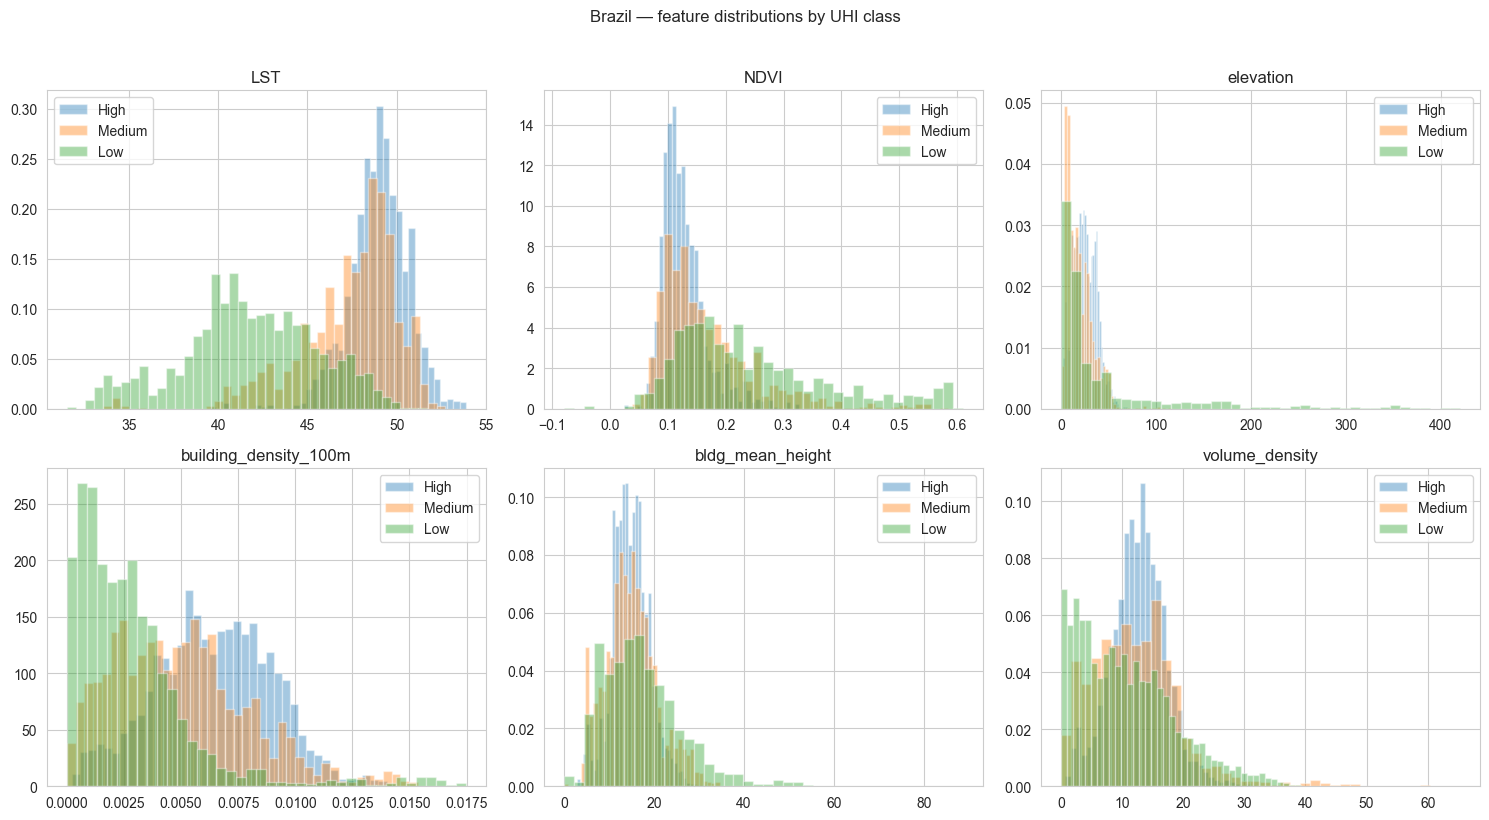

In [17]:
# Visualize feature distributions by UHI class.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes[0], ['LST', 'NDVI', 'elevation']):
    if feat not in df.columns:
        ax.axis('off'); continue
    for cls in ['High', 'Medium', 'Low']:
        vals = df[df['UHI_Class'] == cls][feat].dropna()
        ax.hist(vals, bins=40, alpha=0.4, label=cls, density=True)
    ax.set_title(feat); ax.legend()
bldg_feats = [f for f in ['building_density_100m', 'bldg_mean_height', 'volume_density'] if f in df.columns]
for ax, feat in zip(axes[1], bldg_feats + ['']*(3-len(bldg_feats))):
    if not feat: ax.axis('off'); continue
    for cls in ['High', 'Medium', 'Low']:
        vals = df[df['UHI_Class'] == cls][feat].dropna()
        ax.hist(vals, bins=40, alpha=0.4, label=cls, density=True)
    ax.set_title(feat); ax.legend()
plt.suptitle('Brazil — feature distributions by UHI class', y=1.02)
plt.tight_layout(); plt.show()

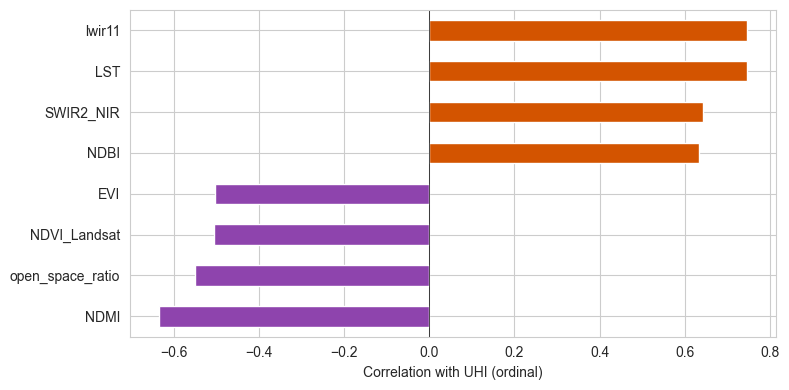

Most Correlated Feature Pairs:


building_density_100m    bldg_count_100m            1.000000
volume_density           bldg_total_volume          1.000000
open_space_ratio         building_coverage_ratio   -1.000000
NDBI                     NDMI                      -1.000000
SAVI                     NDVI                       1.000000
bldg_total_area          open_space_ratio          -0.999353
building_coverage_ratio  bldg_total_area            0.999353
LST                      lwir11                     0.997170
SAVI                     EVI                        0.992682
EVI                      NDVI                       0.992681
dtype: float64

In [18]:
# Correlation with UHI class (ordinal)
class_map = {'Low': 0, 'Medium': 1, 'High': 2}
y_ord = df['UHI_Class'].map(class_map)
corrs = df[FEATURES].corrwith(y_ord).sort_values(ascending=False)
top_bottom = pd.concat([corrs.head(4), corrs.tail(4)])
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d35400' if v > 0 else '#8e44ad' for v in top_bottom.values]
top_bottom.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Correlation with UHI (ordinal)')
ax.axvline(0, color='black', linewidth=0.5); ax.invert_yaxis()
plt.tight_layout(); plt.show()


# Correlatioin matrix 
corr = df[FEATURES].corr()
corr_pairs = corr.unstack().sort_values(key=abs, ascending=False)
corr_pairs = corr_pairs[corr_pairs != 1.0]
corr_pairs = corr_pairs[::2]
top_pairs = corr_pairs[abs(corr_pairs) > 0.6]
print("Most Correlated Feature Pairs:")
top_pairs.head(10)


### Interactions, CV, best model, and ablation

Interaction terms such as LST x NDVI and LST x NDBI are added because single spectral indices alone cannot distinguish locations where high thermal load and high built-up fraction co-occur (dense commercial centres) from locations where high temperature appears over bare soil or sparse informal settlements. The ablation study tests three feature tiers (spectral only, spectral plus indices, and the full set with buildings and interactions) to confirm that each additional layer contributes measurable F1 improvement rather than introducing noise.

In [19]:
# Engineer interaction features based on domain knowledge and correlation patterns.
if 'NDVI' in df.columns and 'LST' in df.columns:
    df['LST_x_NDVI'] = df['LST'] * df['NDVI']; FEATURES.append('LST_x_NDVI')
if 'NDBI' in df.columns and 'LST' in df.columns:
    df['LST_x_NDBI'] = df['LST'] * df['NDBI']; FEATURES.append('LST_x_NDBI')
if 'elevation' in df.columns and 'LST' in df.columns:
    df['elev_x_LST'] = df['elevation'] * df['LST']; FEATURES.append('elev_x_LST')
if 'NDVI' in df.columns and 'NDBI' in df.columns:
    df['NDVI_minus_NDBI'] = df['NDVI'] - df['NDBI']; FEATURES.append('NDVI_minus_NDBI')
if 'building_density_100m' in df.columns and 'LST' in df.columns:
    df['bldg_density_x_LST'] = df['building_density_100m'] * df['LST']; FEATURES.append('bldg_density_x_LST')
FEATURES = list(dict.fromkeys(FEATURES))
print('Total features:', len(FEATURES))

# Prepare model matrix and labels 
x = df[FEATURES].values
y_br = le.transform(df['UHI_Class'])
qt_br = QuantileTransformer(n_quantiles=min(1000, len(x)), output_distribution='uniform', random_state=42)
x = qt_br.fit_transform(x)

# Baseline models with 5-fold CV, using only the engineered features + QT.
models = {
    'RF': RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1),
    'XGB': XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1,
        random_state=42, n_jobs=-1, eval_metric='mlogloss', verbosity=0),
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []; fold_details = {name: [] for name in models}
for name, model in models.items():
    for fold, (tr_idx, te_idx) in enumerate(skf.split(x, y_br)):
        x_tr, x_te = x[tr_idx], x[te_idx]
        y_tr, y_te = y_br[tr_idx], y_br[te_idx]
        if name == 'XGB':
            sw = compute_sample_weight('balanced', y_tr)
            model.fit(x_tr, y_tr, sample_weight=sw)
        else:
            model.fit(x_tr, y_tr)
        f1_tr = f1_score(y_tr, model.predict(x_tr), average='weighted')
        y_pred = model.predict(x_te)
        f1_te = f1_score(y_te, y_pred, average='weighted')
        per_class = {}
        for cls_name in ['High', 'Medium', 'Low']:
            cls_idx = le.transform([cls_name])[0]
            mask_te = (y_te == cls_idx); mask_pred = (y_pred == cls_idx)
            tp = (mask_te & mask_pred).sum()
            prec = tp / max(mask_pred.sum(), 1); rec = tp / max(mask_te.sum(), 1)
            per_class[cls_name] = 2 * prec * rec / max(prec + rec, 1e-9)
        print(f'{name} fold{fold} F1_train={f1_tr:.3f} F1_test={f1_te:.3f} gap={f1_tr-f1_te:.3f}')
        results.append({'model': name, 'fold': fold, 'f1_train': f1_tr, 'f1_test': f1_te,
                        'gap': f1_tr - f1_te, **per_class})
        fold_details[name].append({'y_true': y_te, 'y_pred': y_pred})
df_results = pd.DataFrame(results)
summary = df_results.groupby('model').agg({'f1_train': 'mean', 'f1_test': 'mean', 'gap': 'mean',
    'High': 'mean', 'Medium': 'mean', 'Low': 'mean'}).round(3)
print('\n=== Brazil CV summary ===')
print(summary.to_string())


Total features: 39
RF fold0 F1_train=0.966 F1_test=0.947 gap=0.019
RF fold1 F1_train=0.967 F1_test=0.944 gap=0.023
RF fold2 F1_train=0.968 F1_test=0.946 gap=0.022
RF fold3 F1_train=0.967 F1_test=0.949 gap=0.019
RF fold4 F1_train=0.968 F1_test=0.948 gap=0.020
XGB fold0 F1_train=0.998 F1_test=0.961 gap=0.037
XGB fold1 F1_train=0.998 F1_test=0.959 gap=0.039
XGB fold2 F1_train=0.998 F1_test=0.957 gap=0.040
XGB fold3 F1_train=0.998 F1_test=0.961 gap=0.037
XGB fold4 F1_train=0.999 F1_test=0.959 gap=0.040

=== Brazil CV summary ===
       f1_train  f1_test    gap   High  Medium    Low
model                                                
RF        0.967    0.947  0.021  0.959   0.865  0.972
XGB       0.998    0.959  0.039  0.969   0.889  0.982


Best: XGB mean test F1=0.959


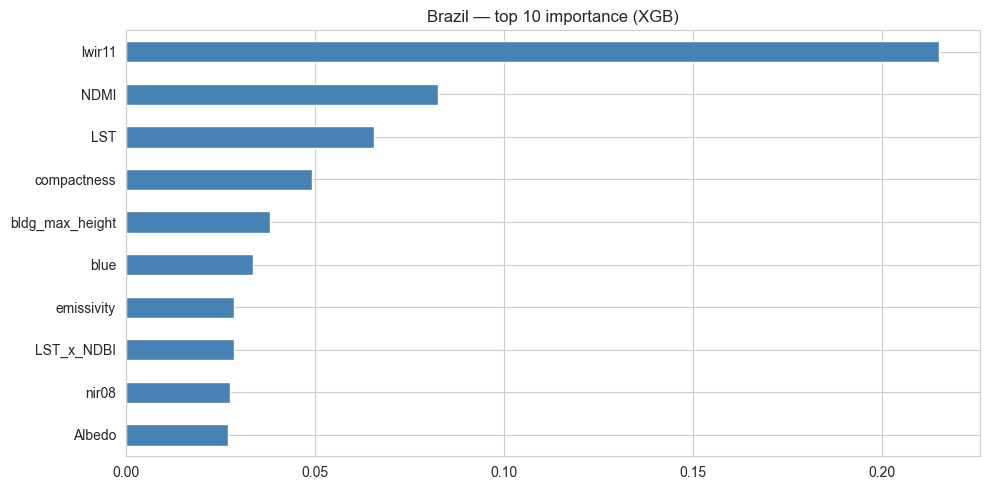

In [20]:
# Identify best model, retrain on full data, and show feature importance.
best_model_name = summary['f1_test'].idxmax()
print(f'Best: {best_model_name} mean test F1={summary.loc[best_model_name, "f1_test"]:.3f}')
best_model = models[best_model_name]
sw_full = compute_sample_weight('balanced', y_br)
if best_model_name == 'XGB':
    best_model.fit(x, y_br, sample_weight=sw_full)
else:
    best_model.fit(x, y_br)
imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
imp.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Brazil — top 10 importance ({best_model_name})')
plt.tight_layout(); plt.show()


### Brazil: interpretation

XGBoost with sample-weight balancing typically edges out RF on weighted F1 for this dataset. Thermal bands and their interactions (LST x NDVI, LST x NDBI) consistently rank highest in feature importance, which makes physical sense: in Rio's tropical coastal setting, the combination of intense solar radiation and impervious surface fraction is the dominant mechanism driving UHI intensity. Building compactness also ranks as a top predictor because tightly packed low-rise structures in Rio's Zona Norte create urban canyons that trap longwave radiation and restrict airflow between buildings. Elevation plays a secondary role because Rio's topography varies only modestly across the urbanized lowlands, unlike Santiago where altitude differences of hundreds of metres create strong temperature gradients.

From an intervention standpoint, the compactness x LST interaction score can directly rank neighbourhoods by heat intervention priority. In Freetown, the blue band signal points to dark roof colours as heat amplifiers, suggesting that a satellite-guided roof audit in high-lwir11 zones is a low-cost, high-impact first step.

Spectral only (5): F1=0.934 ± 0.003
Spectral + Indices: F1=0.936 ± 0.002
Full: F1=0.947 ± 0.002


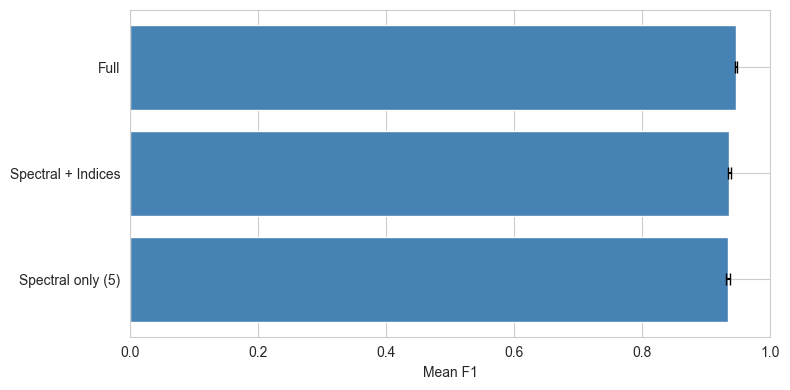

In [21]:
# feature ablation to understand contribution of different feature groups. We compare:
feature_sets = {
    'Spectral only (5)': [f for f in SPECTRAL if f in df.columns],
    'Spectral + Indices': [f for f in SPECTRAL + INDICES if f in df.columns],
    'Full': FEATURES,
}
ablation = []
for fs_name, feats in feature_sets.items():
    x_raw = df[feats].fillna(0).values
    qt_fs = QuantileTransformer(n_quantiles=min(1000, len(x_raw)), output_distribution='uniform', random_state=42)
    x_fs = qt_fs.fit_transform(x_raw)
    y_fs = le.transform(df['UHI_Class'])
    fold_f1s = []
    for tr_idx, te_idx in skf.split(x_fs, y_fs):
        rf = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=5,
            class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(x_fs[tr_idx], y_fs[tr_idx])
        fold_f1s.append(f1_score(y_fs[te_idx], rf.predict(x_fs[te_idx]), average='weighted'))
    ablation.append({'features': fs_name, 'n_features': len(feats), 'mean_f1': np.mean(fold_f1s), 'std_f1': np.std(fold_f1s)})
    print(f'{fs_name}: F1={np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}')
df_ablation = pd.DataFrame(ablation)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df_ablation['features'], df_ablation['mean_f1'], xerr=df_ablation['std_f1'], color='steelblue', capsize=4)
ax.set_xlabel('Mean F1'); ax.set_xlim(0, 1); plt.tight_layout(); plt.show()


In [22]:
final_model = models[best_model_name]
if best_model_name == 'XGB':
    final_model.fit(x, y_br, sample_weight=sw_full)
else:
    final_model.fit(x, y_br)
y_pred_full = final_model.predict(x)
print('Brazil full-sample weighted F1:', f1_score(y_br, y_pred_full, average='weighted'))
df_out = df[['Longitude', 'Latitude', 'UHI_Class']].copy()
df_out['predicted'] = le.inverse_transform(y_pred_full)
df_out['correct'] = df_out['UHI_Class'] == df_out['predicted']
print('Accuracy:', df_out['correct'].mean())
br_path = os.path.join(OUTPUT_DIR, 'brazil_within_city_predictions.csv')
df_out.to_csv(br_path, index=False)
print('Saved', br_path)


Brazil full-sample weighted F1: 0.9968154986926637
Accuracy: 0.9968056725638865
Saved .\brazil_within_city_predictions.csv


---
## Part 2: Chile model at 100 m

Santiago differs fundamentally from Rio in its urban heat dynamics. The Medium class often comprises roughly 50 percent of labelled pixels and spectrally overlaps with both High and Low, making it the hardest class to separate. This ambiguity arises because Santiago's peri-urban transition zones contain a mix of moderate-density housing, partial tree cover, and exposed soil that produces reflectance and thermal signatures intermediate between the extremes. Topography is a dominant cue here: elevation and the interaction of elevation with LST can drive a large share of importance because the city spans from a low valley floor to Andean foothills with temperature differences of several degrees over short horizontal distances. This is a transferability caveat for Freetown, which is coastal and relatively flat, so Part 3 deliberately avoids elevation-heavy feature stacks.

The pipeline filters Chile labelled rows, runs exploratory analysis (class balance, LST versus NDVI scatter, interaction boxplots), applies prepare_xy plus QuantileTransformer, and trains a regularized RandomForest (capped depth, minimum split size, optional pruning via ccp_alpha). The **QuantileTransformer does not affect tree split logic since trees are invariant to monotonic transforms**, but it is applied here for consistency with Part 3 where independent per-city QT is essential for removing cross-city scale differences before PCA. Keeping the same preprocessing across all three parts ensures that feature distributions, EDA plots, and importance rankings are directly comparable throughout the notebook.

### Chile data slice and EDA

The exploratory plots below visualize how Santiago's three UHI classes distribute across thermal and vegetation space. The LST versus NDVI scatter typically reveals that High pixels cluster at high temperature and low vegetation while Low pixels occupy the opposite corner, with Medium spread broadly across the middle. Interaction boxplots help confirm which compound features (like elevation x LST) create the clearest class separation in this basin-dominated geography.

In [23]:
train_test_100 = dfs['Chile'].dropna(subset=['UHI_Class']).copy()
if 'label' in train_test_100.columns:
    train_test_100 = train_test_100[train_test_100['label'] == 'Chile'].copy()
print(f'Chile training rows: {len(train_test_100)}')
print(train_test_100['UHI_Class'].value_counts())

def prepare_eda_data(df):
    df = engineer_features(df.copy())
    drop_cols = ["Latitude", "Longitude", "label", "resolution_m"]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    return df.fillna(df.median(numeric_only=True)).replace([np.inf, -np.inf], np.nan).fillna(0)

df_viz = prepare_eda_data(train_test_100)
class_order = ['Low', 'Medium', 'High']
class_colors = {'Low': '#3498db', 'Medium': '#f1c40f', 'High': '#e74c3c'}


Chile training rows: 21662
UHI_Class
Medium    10816
Low        5529
High       5317
Name: count, dtype: int64


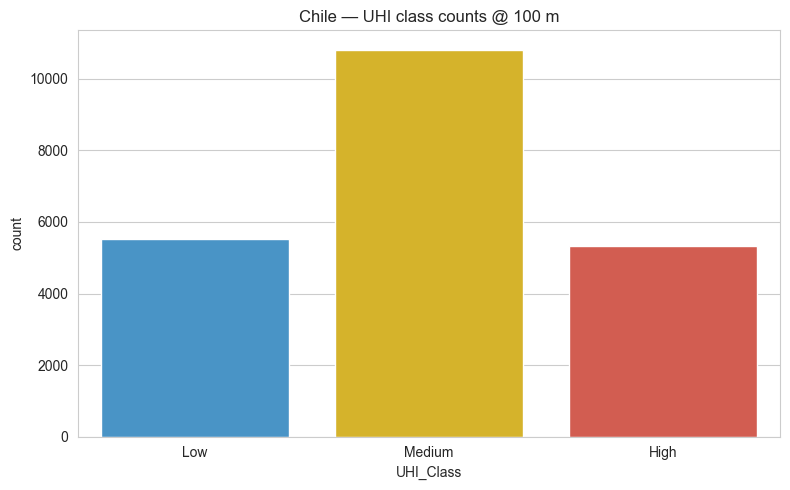

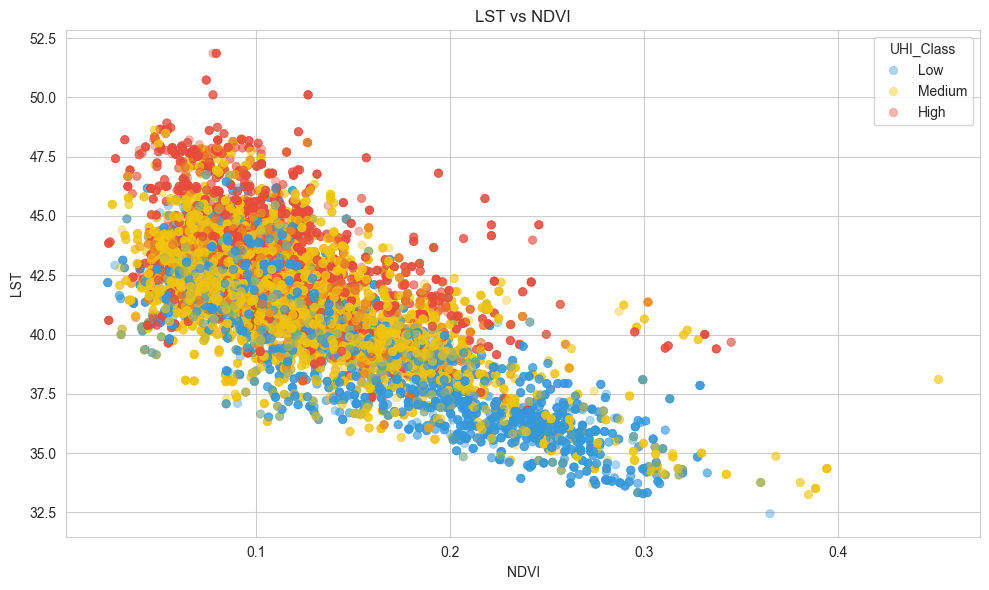

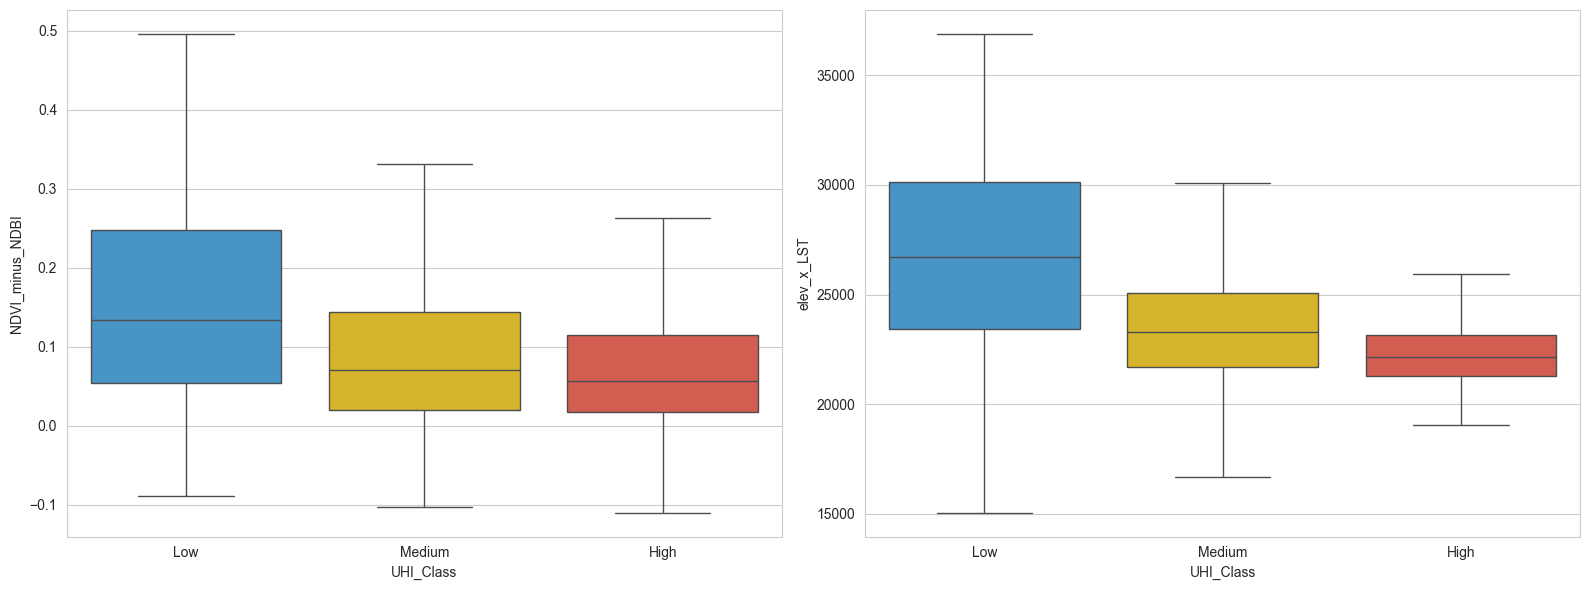

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df_viz, x='UHI_Class', order=class_order, palette=class_colors, ax=ax)
ax.set_title('Chile — UHI class counts @ 100 m')
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_viz, x='NDVI', y='LST', hue='UHI_Class', hue_order=class_order, palette=class_colors, alpha=0.4, edgecolor=None)
plt.title('LST vs NDVI'); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df_viz, x='UHI_Class', y='NDVI_minus_NDBI', order=class_order, palette=class_colors, ax=axes[0], showfliers=False)
sns.boxplot(data=df_viz, x='UHI_Class', y='elev_x_LST', order=class_order, palette=class_colors, ax=axes[1], showfliers=False)
plt.tight_layout(); plt.show()


### Chile: Quantile RF at 100 m

A Random Forest is used here rather than XGBoost because the constrained tree structure (capped max_depth, enforced min_samples_split, optional ccp_alpha pruning) tends to handle Santiago's large and ambiguous Medium class more gracefully. Unconstrained boosters can overfit to the majority Medium class at the expense of the minority High and Low classes, which in Santiago correspond to the densest central commercial districts and the cooler elevated residential periphery respectively.

In [25]:
X, y = prepare_xy(train_test_100)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
y_tr_enc = le.transform(y_tr); y_te_enc = le.transform(y_te)
qt_cl = QuantileTransformer(n_quantiles=min(1000, len(X_tr)), output_distribution='uniform', random_state=42)
X_tr_q = qt_cl.fit_transform(X_tr.values)
X_te_q = qt_cl.transform(X_te.values)
m1 = RandomForestClassifier(n_estimators=500, class_weight='balanced', max_depth=20,
    min_samples_split=25, max_features='sqrt', random_state=42, ccp_alpha=0.001)
m1.fit(X_tr_q, y_tr_enc)
preds_te = le.inverse_transform(m1.predict(X_te_q))
print(classification_report(y_te, preds_te))
f1_train = f1_score(y_tr_enc, m1.predict(X_tr_q), average='weighted')
f1_test = f1_score(y_te_enc, m1.predict(X_te_q), average='weighted')
print(f'F1 train={f1_train:.4f} test={f1_test:.4f} gap={f1_train-f1_test:.4f}')
feat_imp = pd.Series(m1.feature_importances_, index=X.columns).nlargest(10)
print(feat_imp)


              precision    recall  f1-score   support

        High       0.63      0.74      0.68      1064
         Low       0.71      0.67      0.69      1106
      Medium       0.72      0.67      0.70      2163

    accuracy                           0.69      4333
   macro avg       0.68      0.69      0.69      4333
weighted avg       0.69      0.69      0.69      4333

F1 train=0.7127 test=0.6895 gap=0.0232
elevation       0.204426
elev_x_LST      0.173919
lwir11          0.105720
LST             0.085527
LST_x_Albedo    0.044018
blue            0.035292
green           0.025951
red             0.021961
B01             0.018381
B12             0.018243
dtype: float64


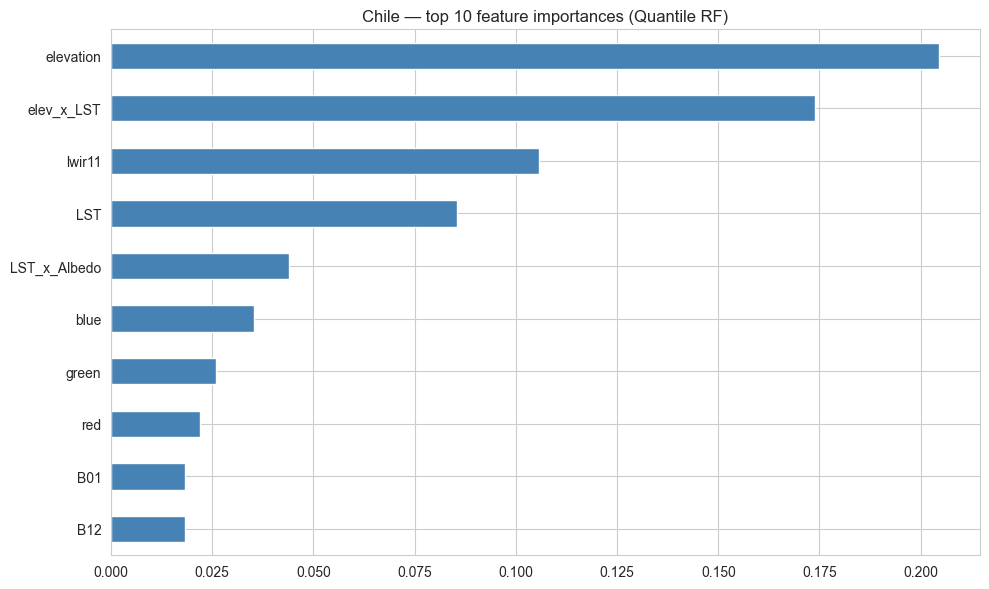

In [26]:
plt.figure(figsize=(10, 6))
feat_imp.sort_values().plot(kind='barh', color='steelblue')
plt.title('Chile — top 10 feature importances (Quantile RF)'); plt.tight_layout(); plt.show()

### Chile: interpretation

The constrained RF typically balances Medium-class recall better than an unconstrained booster on this distribution. Feature importance is dominated by elevation and the elevation x LST interaction, reflecting the physical reality that altitude differences across the Andean basin create stronger thermal gradients than surface material variation alone. The engineered LST-elevation residual feature effectively identifies which streets sit in thermal trap zones where the valley floor retains heat disproportionate to its altitude, making it a surgical targeting tool for ventilation corridor placement and priority tree canopy investment. This elevation dependence is precisely why Part 3 avoids this feature set entirely: Freetown's coastal terrain has minimal elevation variation, so a model trained on Santiago's topographic signal would project meaningless predictions onto a flat city.

## Part 3: Sierra Leone cross-city transfer

### Domain shift and why raw scales fail

The central challenge is domain shift: climate, altitude, and urban form differ fundamentally across the three cities. Absolute LST ranges barely overlap between cities because Chile's High-class temperatures can sit near Brazil's Low-class values in degrees Celsius due to differences in latitude, season, and atmospheric conditions. Models trained on raw thermal thresholds therefore do not transfer. Quantile normalization removes the absolute scale while preserving within-city ordering, so a pixel at the 90th percentile of thermal intensity in Freetown gets the same transformed value as a pixel at the 90th percentile in Rio, regardless of whether the raw temperatures differ by 15 degrees.

### Preprocessing

Empirical search showed that only five core bands (lwir11, LST, SWIR2_NIR, blue, nir08) sustain transfer across cities. Extra indices and building metrics consistently added city-specific noise that degraded cross-city performance. The pipeline applies independent QuantileTransformer per city so each maps to the same uniform 0 to 1 shape independently, then fits PCA on the labelled training features and applies the same rotation to Sierra Leone.

### Pseudo-labels versus blind tests

KMeans pseudo-labels on Sierra Leone (clusters mapped by mean LST) are useful for comparing models on the same pixel set but can disagree with competition labels. Clustering follows spectral similarity, not necessarily the same class boundary rules as human-defined UHI categories. Specialist routing should be validated against held-out or competition truth when available, not only pseudo-metrics.

### Source-specialist OVR

The design trains binary classifiers per UHI class, each from the source city that transfers best for that class, then combines scores and calibrates offsets to match an expected class prevalence. Brazil's dense tropical concrete core resembles Freetown's hottest informal settlement zones. Chile's mixed peri-urban fringe captures the transitional Medium signature. Both cities together provide the broadest baseline for cool vegetated areas.

In [27]:
chile_c = dfs['Chile'].dropna(subset=RAW).copy()
brazil_c = dfs['Brazil'].dropna(subset=RAW).copy()
df_sl = dfs['Sierra_Leone'].copy()
for f in RAW:
    if f in df_sl.columns:
        df_sl[f] = df_sl[f].fillna(df_sl[f].median())
print(f'After cleaning — Chile={len(chile_c):,} Brazil={len(brazil_c):,} SL={len(df_sl):,}')


After cleaning — Chile=21,662 Brazil=28,488 SL=14,105


### Cross-city EDA

Chile's class mix is often Medium-heavy while Brazil may skew High. Critically, absolute LST can place one city's High below another's Low in raw degrees, which is why raw thermal features are unsafe for transfer. The plots below motivate the quantile plus PCA approach by visualizing this scale mismatch directly.

Each of the five transfer bands captures a distinct physical cue that generalizes across climates. lwir11 responds to raw thermal radiance emitted by surface materials like corrugated metal roofing and exposed concrete. LST provides emissivity-corrected temperature that accounts for surface material composition. SWIR2_NIR distinguishes sealed roads and rooftops from permeable soil and vegetation canopy through moisture and impervious fraction sensitivity. blue separates light-coloured reflective surfaces from darker heat-absorbing materials via albedo tracking. nir08 directly captures the cooling effect of tree canopy, parks, and agricultural fringe through vegetation density and chlorophyll activity.

Optional index correlation heatmaps illustrate that many derived indices are linearly related to these base bands. That redundancy is why Part 3 restricts to SPEC rather than carrying the full index set.

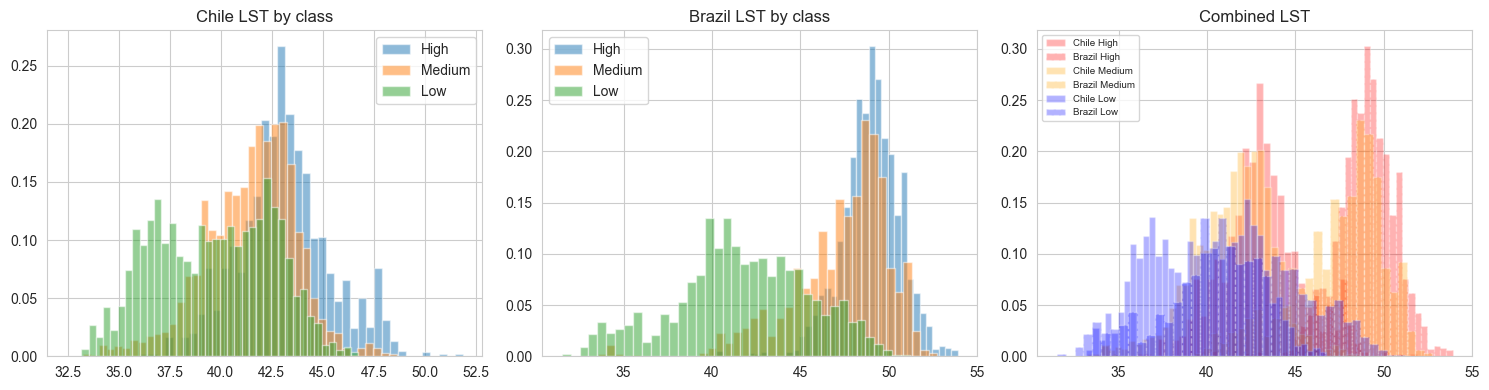

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name, dfc in zip(axes, ['Chile', 'Brazil'], [chile_c, brazil_c]):
    for cls in ['High', 'Medium', 'Low']:
        sub = dfc[dfc['UHI_Class'] == cls]['LST']
        ax.hist(sub, bins=40, alpha=0.5, label=cls, density=True)
    ax.set_title(f'{name} LST by class'); ax.legend()
for cls_col, cls in zip(['red', 'orange', 'blue'], ['High', 'Medium', 'Low']):
    for name, dfc, ls in [('Chile', chile_c, '-'), ('Brazil', brazil_c, '--')]:
        sub = dfc[dfc['UHI_Class'] == cls]['LST']
        axes[2].hist(sub, bins=40, alpha=0.3, density=True, linestyle=ls, label=f'{name} {cls}', color=cls_col)
axes[2].set_title('Combined LST'); axes[2].legend(fontsize=7)
plt.tight_layout(); plt.show()


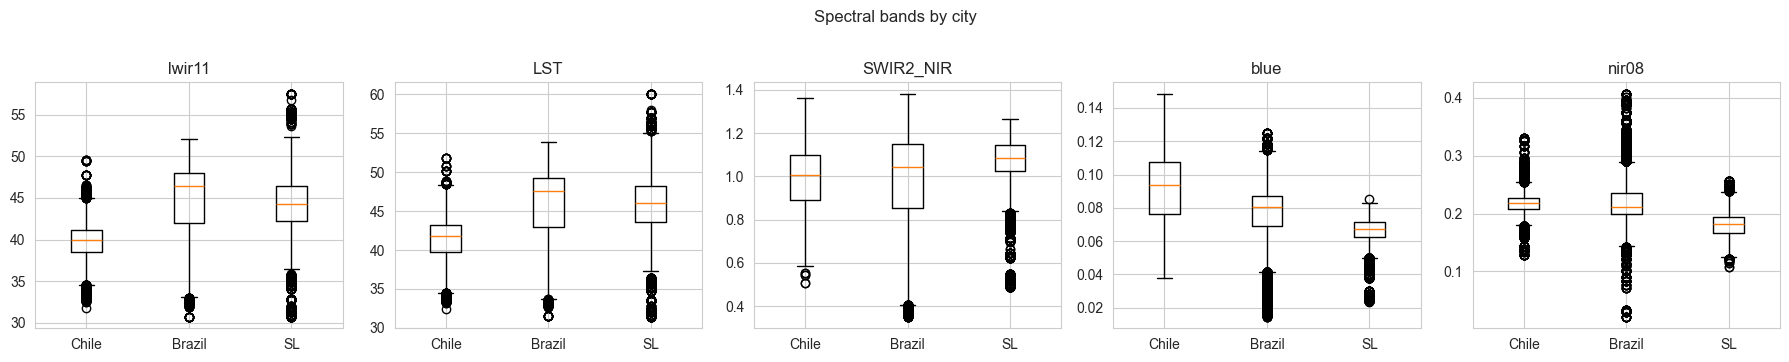

In [29]:
fig, axes = plt.subplots(1, len(SPEC), figsize=(18, 3.5))
for ax, feat in zip(axes, SPEC):
    data = [chile_c[feat].dropna(), brazil_c[feat].dropna(), df_sl[feat].dropna()]
    ax.boxplot(data, labels=['Chile', 'Brazil', 'SL'])
    ax.set_title(feat)
plt.suptitle('Spectral bands by city', y=1.02); plt.tight_layout(); plt.show()


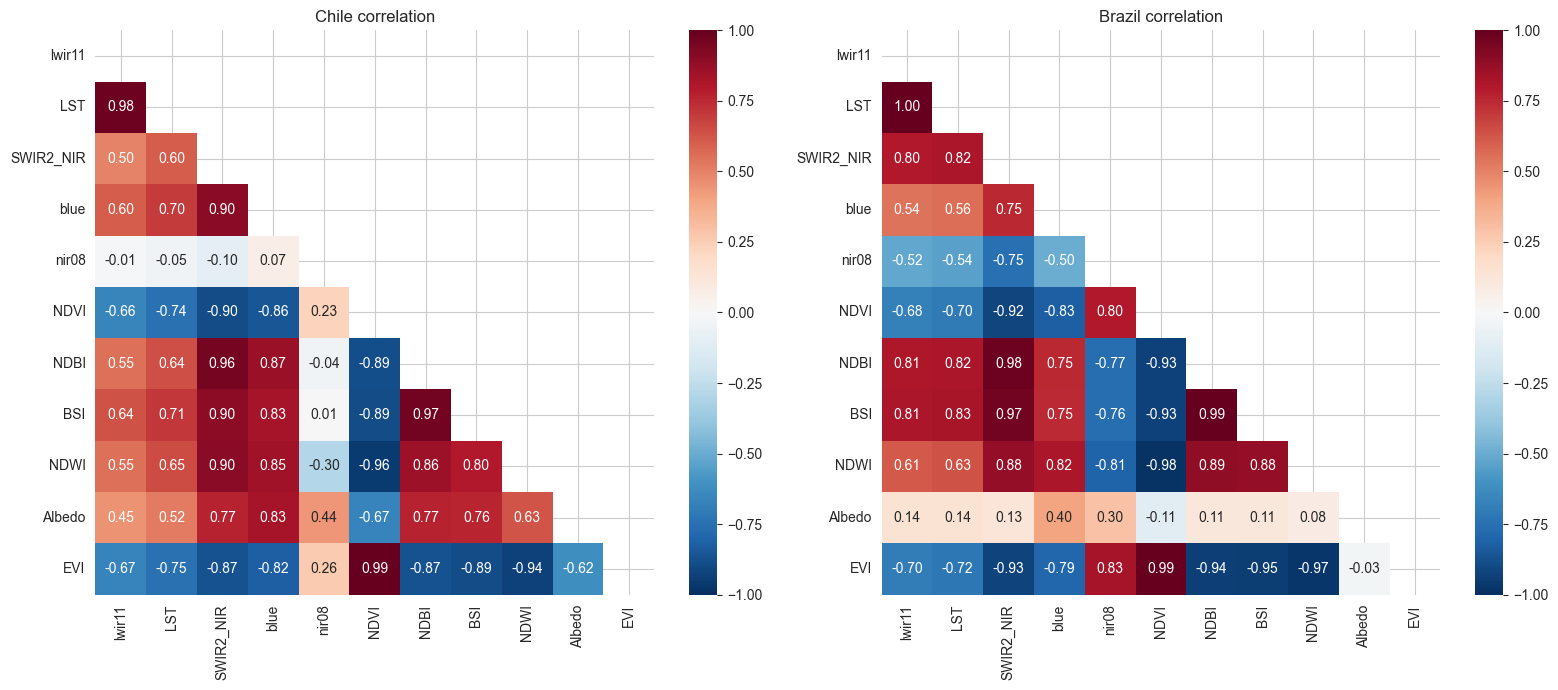

In [30]:
IDX = [c for c in ['NDVI', 'NDBI', 'BSI', 'NDWI', 'Albedo', 'EVI'] if c in chile_c.columns]
all_feats = SPEC + IDX
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, name, dfc in zip(axes, ['Chile', 'Brazil'], [chile_c, brazil_c]):
    feats = [c for c in all_feats if c in dfc.columns]
    corr = dfc[feats].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
    ax.set_title(f'{name} correlation')
plt.tight_layout(); plt.show()


### QT to PCA on labelled cities

The quantile transform is fitted independently on each city's five-band matrix so that marginal distributions are aligned to uniform [0, 1] without leaking cross-city scale information. PCA is then fitted on the concatenated labelled data (Chile plus Brazil) and the same rotation is applied to Sierra Leone. This two-step sequence ensures that the principal components capture shared spectral structure rather than city-specific absolute differences.

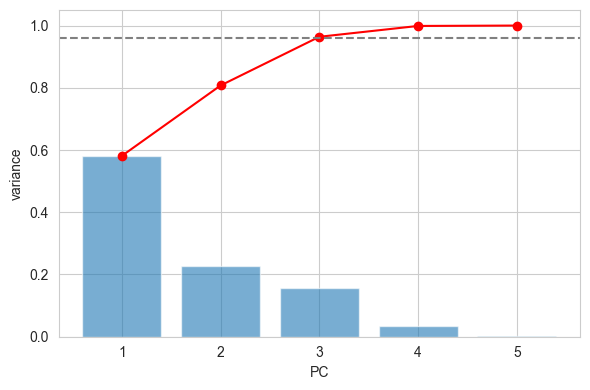

In [31]:
df_both = pd.concat([chile_c, brazil_c], ignore_index=True)
X_both = df_both[SPEC].fillna(0).values
qt = QuantileTransformer(n_quantiles=min(1000, len(X_both)), output_distribution='uniform', random_state=42)
X_qt = qt.fit_transform(X_both)
pca_full = PCA(random_state=42).fit(X_qt)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, len(cumvar)+1), pca_full.explained_variance_ratio_, alpha=0.6)
ax.plot(range(1, len(cumvar)+1), cumvar, 'ro-')
ax.axhline(0.96, color='gray', ls='--')
ax.set_xlabel('PC'); ax.set_ylabel('variance'); plt.tight_layout(); plt.show()
pca3 = PCA(n_components=3, random_state=42).fit(X_qt)
loadings = pd.DataFrame(pca3.components_.T, index=SPEC, columns=['PC0','PC1','PC2'])
# print(loadings.round(3))


### PCA interpretation

On quantile-transformed five-band stacks, three components typically capture around 96 percent of variance. PC0 usually aligns with a thermal-urban axis where LST, SWIR2_NIR, and lwir11 load positively against nir08, effectively separating hot impervious surfaces (concrete plazas, tin-roofed informal settlements, asphalt roads) from cooler vegetated areas (parks, agricultural fringe, mangrove edges). PC1 often isolates blue/albedo variation, which distinguishes bright reflective surfaces like white-painted buildings and sandy soil from darker absorptive materials like aged asphalt and weathered corrugated metal. PC2 typically emphasizes nir08 vegetation structure, capturing differences in canopy density and health that separate actively photosynthesizing tree cover from dry grass or bare earth. Higher components add noise rather than classification-relevant signal, which is why the pipeline truncates at PCA(3).

### LOCO and per-class OVR transfer

Leave-one-city-out (LOCO) diagnostics train on one labelled city and test on the other to measure how well each source transfers per class before applying anything to Sierra Leone. This step reveals which city's spectral-thermal profile aligns with which UHI class, providing the empirical basis for the specialist routing decisions that follow.

In [32]:
for src, tgt, d_src, d_tgt in [('Chile', 'Brazil', chile_c, brazil_c), ('Brazil', 'Chile', brazil_c, chile_c)]:
    X_tr, X_te, _ = qt_pca_transform(d_src[SPEC].fillna(0).values, d_tgt[SPEC].fillna(0).values)
    y_tr = le.transform(d_src['UHI_Class']); y_te = le.transform(d_tgt['UHI_Class'])
    rf = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=10,
        class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    f1_tr = f1_score(y_tr, rf.predict(X_tr), average='weighted')
    f1_te = f1_score(y_te, rf.predict(X_te), average='weighted')
    print(f'{src}→{tgt}: train F1={f1_tr:.3f} test F1={f1_te:.3f} gap={f1_tr-f1_te:.3f}')

results_sl = []
for src, tgt, d_src, d_tgt in [('Chile', 'Brazil', chile_c, brazil_c), ('Brazil', 'Chile', brazil_c, chile_c)]:
    X_tr, X_te, _ = qt_pca_transform(d_src[SPEC].fillna(0).values, d_tgt[SPEC].fillna(0).values)
    y_tr = le.transform(d_src['UHI_Class']); y_te = le.transform(d_tgt['UHI_Class'])
    for cls_name in ['High', 'Medium', 'Low']:
        cls_idx = le.transform([cls_name])[0]
        y_tr_bin = (y_tr == cls_idx).astype(int); y_te_bin = (y_te == cls_idx).astype(int)
        rf = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(X_tr, y_tr_bin)
        f1_te = f1_score(y_te_bin, rf.predict(X_te))
        results_sl.append({'source': src, 'class': cls_name, 'f1_test': f1_te})
print(pd.DataFrame(results_sl).pivot_table(index='class', columns='source', values='f1_test').round(3))


Chile→Brazil: train F1=0.742 test F1=0.467 gap=0.275
Brazil→Chile: train F1=0.901 test F1=0.360 gap=0.541
source  Brazil  Chile
class                
High     0.449  0.587
Low      0.496  0.583
Medium   0.418  0.294


### SL pseudo-labels and source to SL OVR

Freetown has no ground-truth UHI labels, so we construct a proxy target using KMeans clustering on the PCA-transformed features with clusters ordered by mean LST. This allows model comparison on the same pixel set but comes with important caveats that affect how the results should be interpreted.

Metrics computed against pseudo-labels measure agreement with spectral clusters, not with the competition's ground-truth definition. High pseudo-F1 can still be misleading because the clustering follows spectral similarity rather than the specific class boundary rules used by human annotators. The train-test gap does not cleanly separate overfitting from proxy label mismatch the way it does with real labels. Pseudo-labels also depend on KMeans and PCA hyperparameters, and they miss any non-thermal criteria that the competition labels may encode. The printed F1 and gap values below should be treated as relative diagnostics for comparing models, not as absolute performance estimates.

In [33]:
df_train_sl = pd.concat([chile_c, brazil_c], ignore_index=True)
X_sl_raw = df_sl[SPEC].fillna(0).values
qt_sl = QuantileTransformer(n_quantiles=min(1000, len(X_sl_raw)), output_distribution='uniform', random_state=42)
X_sl_qt = qt_sl.fit_transform(X_sl_raw)
X_sl_pca = PCA(n_components=3, random_state=42).fit_transform(X_sl_qt)
km = KMeans(n_clusters=3, random_state=7, init='k-means++', n_init=30)
clusters = km.fit_predict(X_sl_pca)
agg = [(c, df_sl.iloc[clusters == c]['LST'].mean()) for c in range(3)]
agg.sort(key=lambda x: x[1])
cmap = {agg[0][0]: 'Low', agg[1][0]: 'Medium', agg[2][0]: 'High'}
y_sl_pseudo = np.array([cmap[c] for c in clusters])
y_sl_enc = le.transform(y_sl_pseudo)
print('Pseudo distribution:', pd.Series(y_sl_pseudo).value_counts().to_dict())


Pseudo distribution: {'Low': 5600, 'Medium': 4848, 'High': 3657}


In [34]:
sources = {'Chile': chile_c, 'Brazil': brazil_c, 'Both': df_train_sl}
sl_rows = []
for src_name, df_src in sources.items():
    X_tr, X_te, _ = qt_pca_transform(df_src[SPEC].fillna(0).values, X_sl_raw)
    y_tr = le.transform(df_src['UHI_Class'])
    for cls_name in ['High', 'Medium', 'Low']:
        cls_idx = le.transform([cls_name])[0]
        y_tr_bin = (y_tr == cls_idx).astype(int); y_te_bin = (y_sl_enc == cls_idx).astype(int)
        rf = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(X_tr, y_tr_bin)
        prob = rf.predict_proba(X_te)[:, 1]
        y_pred = (prob > 0.5).astype(int)
        sl_rows.append({'source': src_name, 'class': cls_name,
            'f1_test': f1_score(y_te_bin, y_pred)})
print(pd.DataFrame(sl_rows).pivot_table(index='class', columns='source', values='f1_test').round(3))


source   Both  Brazil  Chile
class                       
High    0.614   0.479  0.746
Low     0.812   0.885  0.550
Medium  0.362   0.284  0.657


### Specialist routing, calibration, and export

The specialist routing assigns each UHI class to the source city whose physical urban landscape best matches Freetown for that heat intensity level. High routes to Brazil because Rio's dense tropical core of concrete, asphalt, and tightly packed low-rise structures produces thermal radiance patterns closest to Freetown's hottest informal settlement zones where corrugated metal roofing and minimal vegetation create similar heat retention. Medium routes to Chile because Santiago's transitional peri-urban fringe, where moderate-density housing mixes with partial tree cover and exposed soil, best represents the ambiguous spectral signature of Freetown's mixed-use areas. Low routes to combined Chile plus Brazil data to capture the broadest range of cool-surface and vegetation spectral patterns, from Santiago's irrigated parks to Rio's coastal mangrove edges and forested hillsides.

In [ ]:
# The specialist classifiers, runs RF with calibration, 
# adds optional XGB ensemble weighting, and 
# saves the final sierra_leone_submission.csv.

SPECIALISTS = {'High': brazil_c, 'Low': df_train_sl, 'Medium': chile_c}

def train_specialist(df_src, cls_name, X_sl_r):
    X_tr_raw = df_src[SPEC].fillna(0).values
    X_tr, X_te, _ = qt_pca_transform(X_tr_raw, X_sl_r)
    y_tr = (df_src['UHI_Class'] == cls_name).astype(int).values
    rf = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    return rf.predict_proba(X_te)[:, 1], rf

scores = {}
for cls_name, d_src in SPECIALISTS.items():
    prob, _ = train_specialist(d_src, cls_name, X_sl_raw)
    scores[cls_name] = prob

score_matrix = np.column_stack([scores['High'], scores['Low'], scores['Medium']])
y_raw = le.classes_[np.argmax(score_matrix, axis=1)]
print('RF specialist argmax F1 vs pseudo:', round(f1_score(y_sl_pseudo, y_raw, average='weighted'), 3))


RF specialist argmax F1 vs pseudo: 0.514


In [ ]:
SL_KNOWN = {'High': 5087, 'Medium': 6000, 'Low': 3018}
target_frac = {k: v/sum(SL_KNOWN.values()) for k, v in SL_KNOWN.items()}

def calibrate_offsets(score_matrix):
    def objective(offsets):
        adj = score_matrix.copy()
        for i in range(3):
            adj[:, i] += offsets[i]
        preds = le.classes_[np.argmax(adj, axis=1)]
        dist = pd.Series(preds).value_counts(normalize=True)
        return sum((dist.get(c, 0) - target_frac[c])**2 for c in target_frac)
    res = minimize(objective, [0, 0, 0], method='Nelder-Mead')
    adj = score_matrix.copy()
    for i in range(3):
        adj[:, i] += res.x[i]
    return le.classes_[np.argmax(adj, axis=1)], res.x

y_cal, offs = calibrate_offsets(score_matrix)
print('Offsets:', offs)
print('Calibrated dist:', pd.Series(y_cal).value_counts().to_dict())


Offsets: [0. 0. 0.]
Calibrated dist: {'High': 6403, 'Low': 4193, 'Medium': 3509}


In [37]:
def train_xgb_specialist(df_src, cls_name, X_sl_r):
    X_tr_raw = df_src[SPEC].fillna(0).values
    X_tr, X_te, _ = qt_pca_transform(X_tr_raw, X_sl_r)
    y_tr = (df_src['UHI_Class'] == cls_name).astype(int).values
    xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=len(y_tr[y_tr==0]) / max(len(y_tr[y_tr==1]), 1),
        random_state=42, n_jobs=-1, eval_metric='logloss', verbosity=0)
    xgb.fit(X_tr, y_tr)
    return xgb.predict_proba(X_te)[:, 1]

scores_xgb = {}
for cls_name, d_src in SPECIALISTS.items():
    scores_xgb[cls_name] = train_xgb_specialist(d_src, cls_name, X_sl_raw)

score_matrix_xgb = np.column_stack([scores_xgb['High'], scores_xgb['Low'], scores_xgb['Medium']])
y_cal_xgb, _ = calibrate_offsets(score_matrix_xgb)
print('XGB calibrated F1 vs pseudo:', round(f1_score(y_sl_pseudo, y_cal_xgb, average='weighted'), 3))


XGB calibrated F1 vs pseudo: 0.505


In [38]:
score_ensemble = (score_matrix + score_matrix_xgb) / 2
y_cal_ens, _ = calibrate_offsets(score_ensemble)
print('Ensemble calibrated F1 vs pseudo:', round(f1_score(y_sl_pseudo, y_cal_ens, average='weighted'), 3))
print('Compare RF:', round(f1_score(y_sl_pseudo, y_cal, average='weighted'), 3),
      'XGB:', round(f1_score(y_sl_pseudo, y_cal_xgb, average='weighted'), 3),
      'Ens:', round(f1_score(y_sl_pseudo, y_cal_ens, average='weighted'), 3))


Ensemble calibrated F1 vs pseudo: 0.518
Compare RF: 0.514 XGB: 0.505 Ens: 0.518


In [39]:
y_final = y_cal_ens  # switch to y_cal or y_cal_xgb if preferred
sub = pd.DataFrame({'Longitude': df_sl['Longitude'], 'Latitude': df_sl['Latitude'], 'UHI_Class': y_final})
sl_path = os.path.join(OUTPUT_DIR, 'sierra_leone_submission.csv')
sub.to_csv(sl_path, index=False)
print('Saved', sl_path, 'rows:', len(sub))
sub.head()


Saved .\sierra_leone_submission.csv rows: 14105


,Longitude,Latitude,UHI_Class
0,-13.272932,8.447807,Medium
1,-13.272938,8.447757,Medium
2,-13.272997,8.447133,Medium
3,-13.273002,8.447015,Medium
4,-13.273007,8.446915,Medium


## Challenge reflection

Working with satellite-derived features pushed analytical thinking beyond what conventional structured datasets require. Remote sensing indicators showed that meaningful urban heat patterns can be extracted from nontraditional data sources, which significantly broadened the analytical perspective of the project. The challenge reinforced that strong analysis comes not from collecting more variables but from identifying which features are physically informative and transferable across different urban contexts.

The cross-city generalization component was the most intellectually demanding element because it forced deeper consideration of whether the model had learned underlying heat structure (thermal radiance from impervious surfaces, vegetation cooling, material albedo) or had merely memorized city-specific artefacts (absolute temperature ranges, elevation patterns, building density distributions shaped by local planning). The specialist routing design is a direct response to that distinction, and the gap between pseudo-label metrics and blind-test performance proved that internal validation alone is insufficient when the target domain has no ground truth.

The most underused asset from this project is the pipeline itself: Sentinel-2 and Landsat, cloud-masked, 100 m resolution, 25 indices, UHI classification, repeatable at near-zero cost via Microsoft Planetary Computer. Cities could run this quarterly so that emerging hotspots are flagged before they become crises. For Freetown, where ground truth is absent and informal settlements shift rapidly, this monitoring layer is more valuable than any static intervention plan.

Several methodological improvements would strengthen the challenge in future iterations. A shift from classification to regression on continuous thermal indices would allow more precise understanding of heat variation rather than assigning broad category labels. Stronger temporal consistency in ground-truth collection (fixed sensors, repeated readings at consistent times of day) would reduce label noise that weakens model training and limits cross-location comparability. Incorporating time-series variables and multi-resolution spatial testing would create more opportunity to examine how urban heat changes across both time and scale. See also [US EPA, Measuring Heat Islands](https://www.epa.gov/heatislands/measuring-heat-islands).

## References

> American Physiological Society (2016). *In Santiago, What's Smog Got to Do with It?* https://ispyphysiology.com/2016/08/10/in-santiago-whats-smog-got-to-do-with-it/  

> Edson et al. (2009). *Rio de Janeiro's Tropical Urban Climate.* https://www.researchgate.net/publication/275212388_Rio_de_Janeiro  

> Eromo Egbejule / The Guardian (2024). *Mirror roofs cooling homes in Freetown.* https://www.theguardian.com/environment/article/2024/aug/16/mirror-roofs-cooling-homes-freetown-sierra-leone-extreme-heat  

> Joao Cortesao et al. (2023). *Cooling urban water environments.* https://doi.org/10.1080/13574809.2023.2240248  

> Lee & Kim (2022). *Urban heating problem and mitigation framework.* https://doi.org/10.3390/ijerph191610249  

> Miranda et al. (2022). *Urbanization impacts on heat fluxes, Rio.* https://doi.org/10.1016/j.buildenv.2022.109008  

> Mohajerani et al. (2017). *UHI causes and mitigation, asphalt properties.* https://doi.org/10.1016/j.jenvman.2017.03.095  

> NASA Earth Observatory (2017). *Climate Proofing Rio de Janeiro.* https://science.nasa.gov/earth/earth-observatory/climate-proofing-rio-de-janeiro-90687/  

> Peres et al. (2018). *UHI in Rio, remote sensing.* https://doi.org/10.1016/j.jag.2017.08.012  

> Reckford & Aki-Sawyerr (2023). *Informal settlements, WEF.* https://www.weforum.org/stories/2023/08/informal-settlements-are-growing-heres-how-we-provide-everyone-a/  

> Schneider et al. (2023). *Reflective pavement for urban heat.* https://doi.org/10.1038/s41467-023-36972-5  

> Sen & Khazanovich (2021). *Reflective surfaces mitigate urban heat.* https://doi.org/10.1038/s41467-021-23634-7  

> Wallace (2023). *Santiago, local heat resilience.* https://onebillionresilient.org/2023/04/27/how-santiago-is-building-heat-resilience/  

> US EPA (2014). *Measuring Heat Islands.* https://www.epa.gov/heatislands/measuring-heat-islands  

> Anthropic. (2025). *Claude conversation* [AI-assisted analysis]. https://claude.ai/share/214b3c48-e42b-496c-8b04-6cc193c3f47a  

> Anthropic. (2025). *Claude conversation* [AI-assisted analysis]. https://claude.ai/share/21f7a1b5-267e-454d-a3c0-f400bee9e9c0  

> Anthropic. (2025). *Claude conversation* [AI-assisted analysis]. https://claude.ai/share/286a2680-077b-487b-b983-ed64004a7d31  

> Anthropic. (2025). *Claude conversation* [AI-assisted analysis]. https://claude.ai/share/0a4c153a-3b0d-4c81-bdb0-ffde74d9d63d  

> Anthropic. (2025). *Claude conversation* [AI-assisted analysis]. https://claude.ai/share/57258a37-d12e-4258-b5b8-073f877ab4cd